# Gabazine files

In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

# BXR

In [2]:
from preprocess_bxr import *

fileDirectory_base = "data\\gbz_baseline_data\\"
fileName_base = '20251110_DissOrg_T-line_CoCu_BP-10_2088_DIV-61_baseline_00.bxr' # name of BXR file 

fileDirectory_treat = "data\\gbz_treat_data\\"
fileName_treat = '20251110_DissOrg_T-line_CoCu_BP-10_2088_DIV-61_gabazine_00.bxr' # name of BXR file 

wf_base = extract_waveforms_from_bxr(fileDirectory_base, fileName_base)
wf_treat = extract_waveforms_from_bxr(fileDirectory_treat, fileName_treat)

wf_base_preprocessed = preprocess_waveforms_meanfirst(
    wf_base,
    smoothing_method = None, #'gf',
    smoothing_kwargs = None, #{'sigma': 1.5},
    min_waveforms=25, 
    norm=True,
    export_csv=True,
    isteps=10,
    max_initial_amp=0.25,
    peak_prominence=0.3,
    export_filename="BXR_mean_waveforms_preprocessed_gbz_baseline.csv")

wf_treat_preprocessed = preprocess_waveforms_meanfirst(
    wf_treat,
    smoothing_method = None, #'gf',
    smoothing_kwargs = None, #{'sigma': 1.5},
    min_waveforms=25,  
    norm=True,
    export_csv=True,
    isteps=10,
    max_initial_amp=0.25,
    peak_prominence=0.3,
    export_filename="BXR_mean_waveforms_preprocessed_gbz_treat.csv")

Saved 155 rows to: BXR_mean_waveforms_preprocessed_gbz_baseline.csv
Saved 165 rows to: BXR_mean_waveforms_preprocessed_gbz_treat.csv


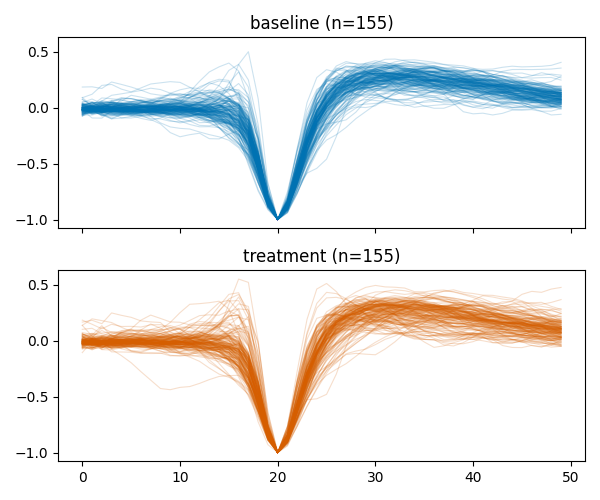

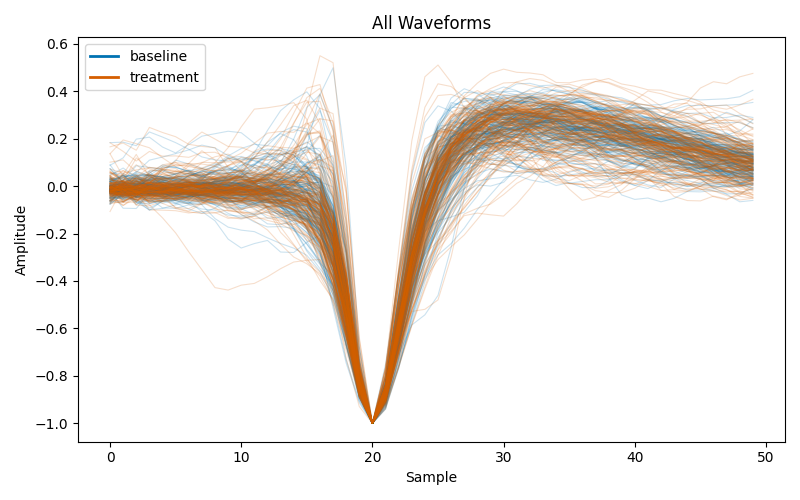

In [33]:
# .bxr ones to compare to

data_path_base = "d:\\MasterThesis\\BXR_mean_waveforms_preprocessed_gbz_baseline.csv"
data_path_treat = "d:\\MasterThesis\\BXR_mean_waveforms_preprocessed_gbz_treat.csv"

data_list = [data_path_base, data_path_treat] 
data_labels = ['baseline', 'treatment']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)


# BRW (only baseline)

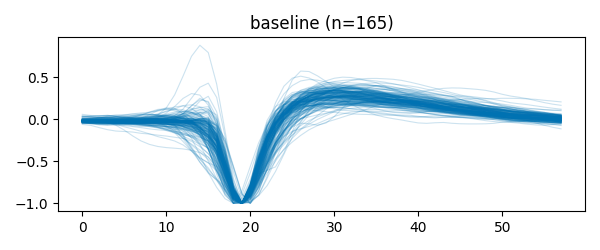

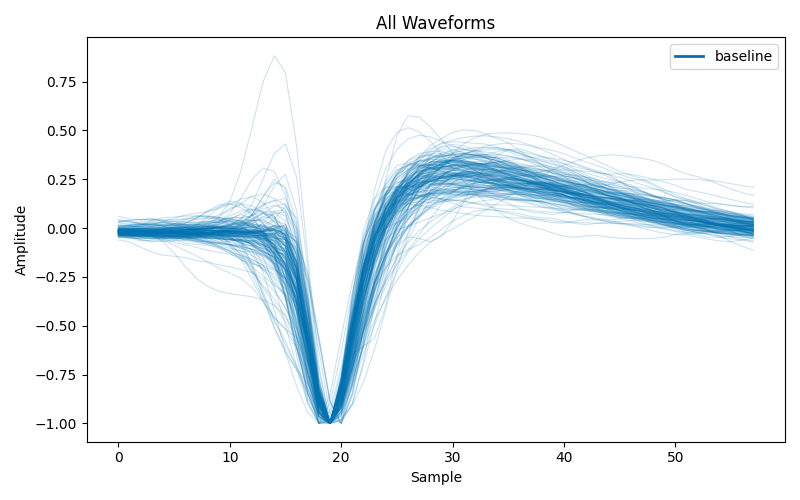

In [95]:
# Load the preprocessed noflip25 data

data_path_base = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_baseline.csv"

data_list = [data_path_base] 
data_labels = ['baseline']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)

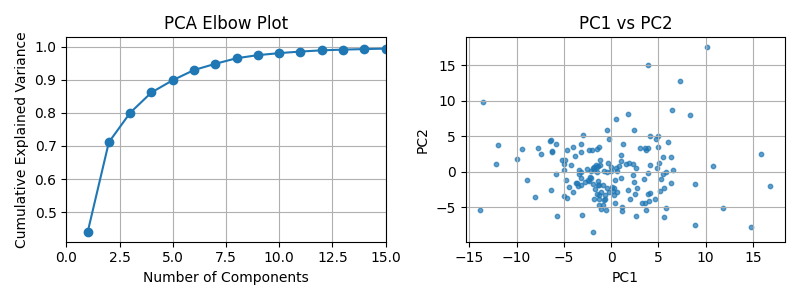

Components that explain 90% of variance: 6


In [96]:
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


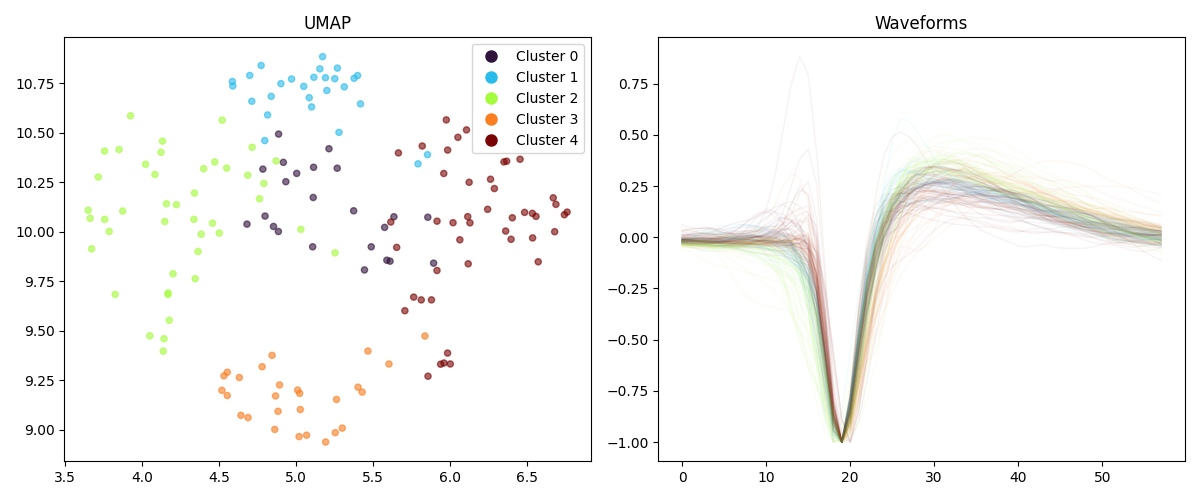

In [97]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=20, min_d=0.1, n_comps=8, resolution = 2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP with dataset labels
interactive_umap_clusters(umap_df)

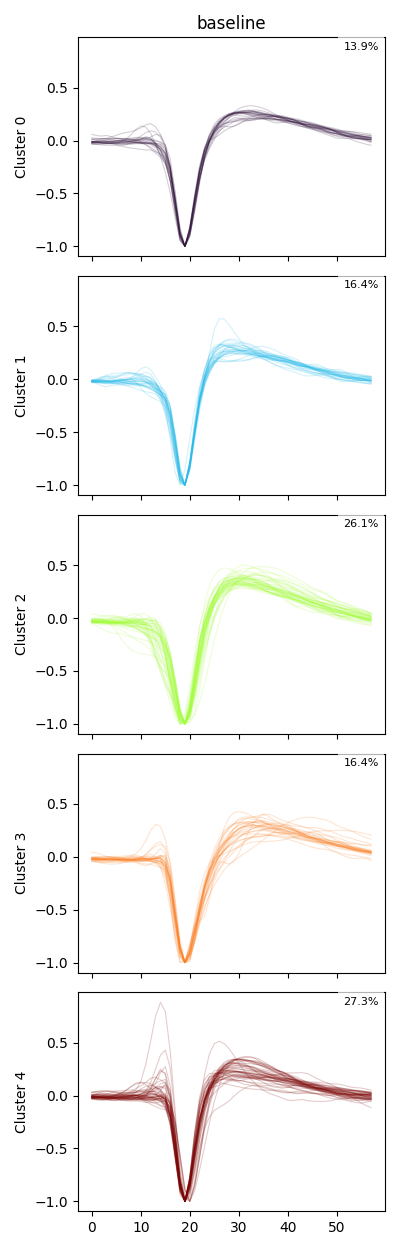

In [98]:
plot_cluster_waveforms(umap_df,plot_mean=False,alpha=0.2, figsize_per_panel=(4, 2.5))

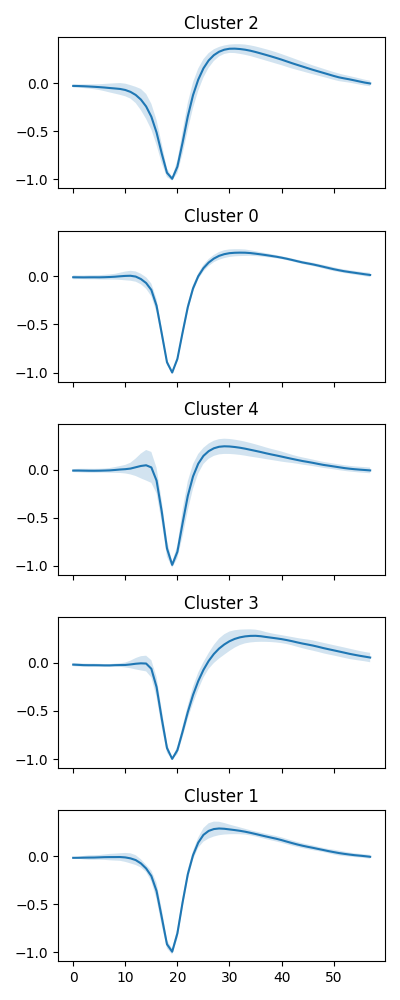

In [99]:
plt.close()

clusters = umap_df['cluster_id'].unique()
n_clusters = len(clusters)

fig, axes = plt.subplots(n_clusters, 1, figsize=(4, 2*n_clusters), sharex=True, sharey=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df[umap_df['cluster_id'] == cluster]
    
    waves = np.vstack(cluster_data['waveform'])
    
    mean = waves.mean(axis=0)
    std = waves.std(axis=0)
    
    ax.plot(mean)
    ax.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)
    
    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()

# BRW (only treatment)

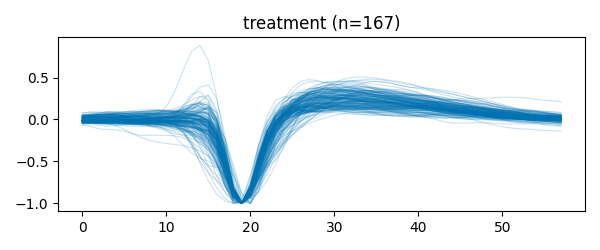

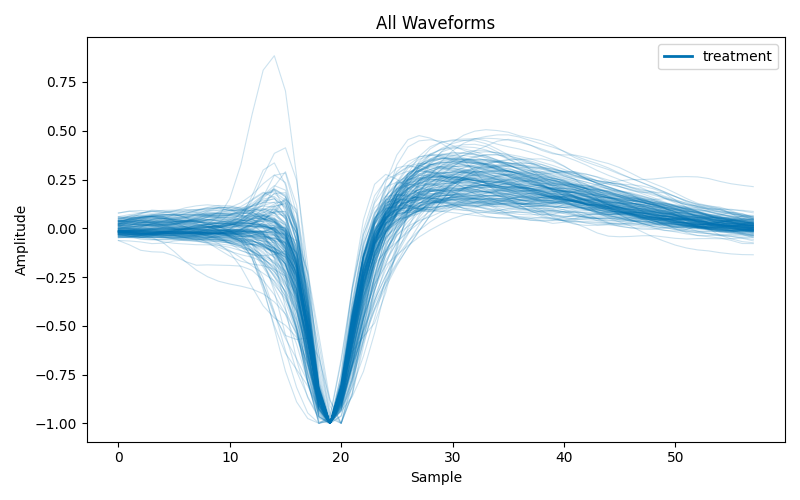

In [100]:
data_path_base = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_treat.csv"

data_list = [data_path_treat] 
data_labels = ['treatment']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)

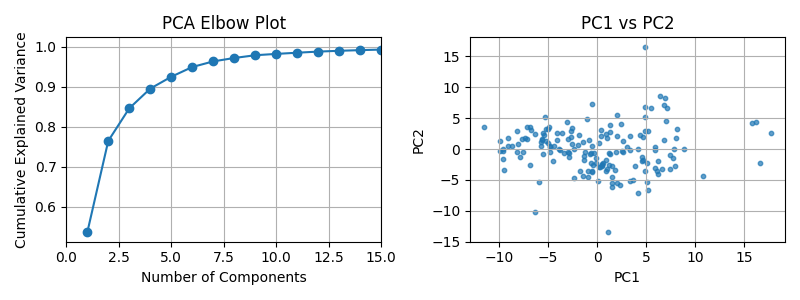

Components that explain 90% of variance: 5


In [101]:
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


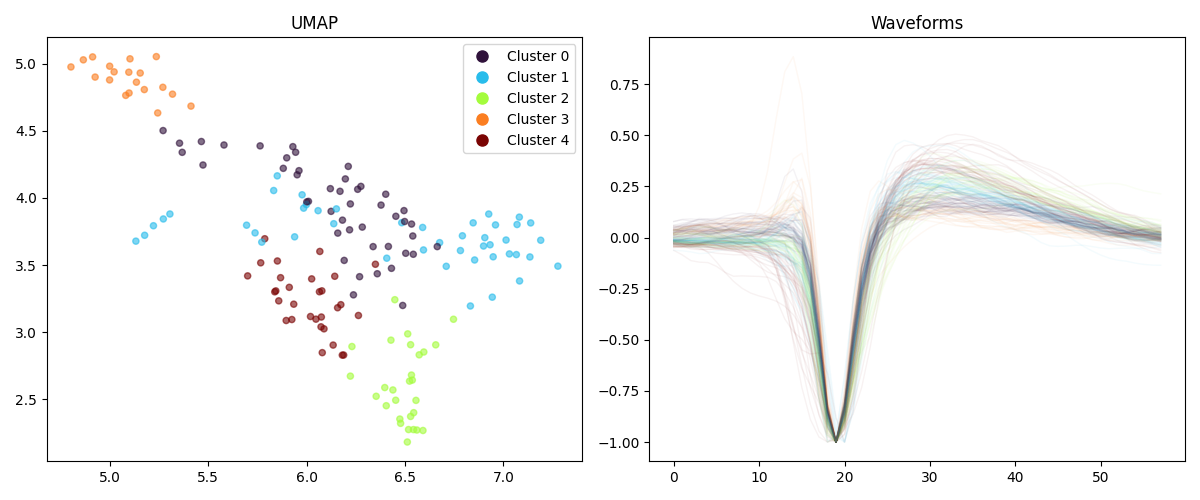

In [102]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=20, min_d=0.1, n_comps=8, resolution = 2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP with dataset labels
interactive_umap_clusters(umap_df)

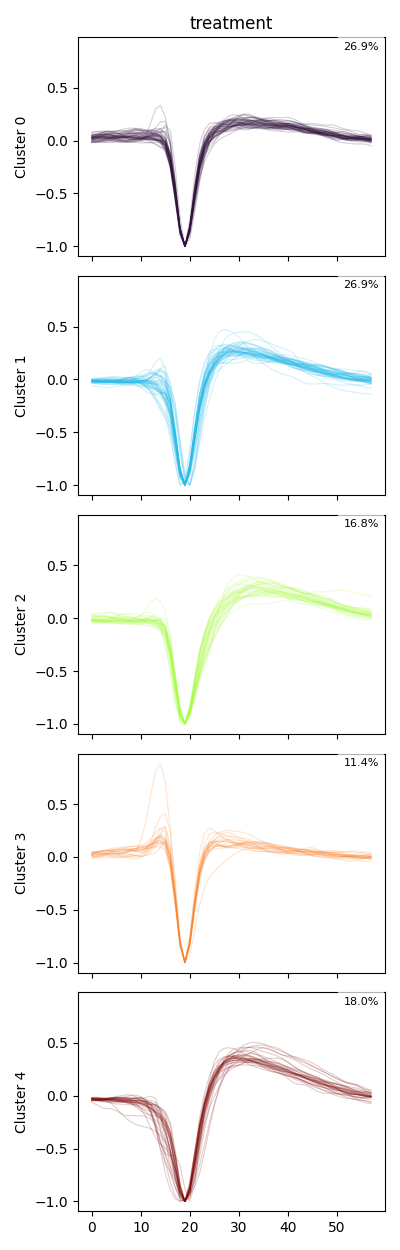

In [105]:
plot_cluster_waveforms(umap_df,plot_mean=False,alpha=0.2, figsize_per_panel=(4, 2.5))

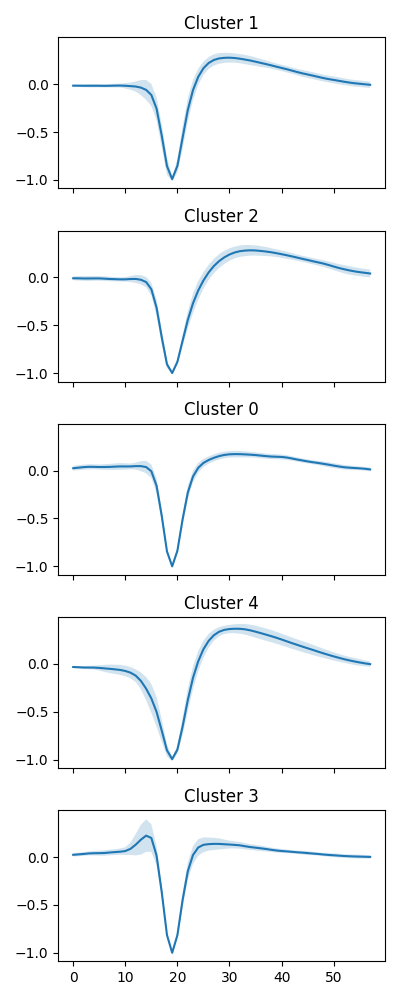

In [106]:
plt.close()

clusters = umap_df['cluster_id'].unique()
n_clusters = len(clusters)

fig, axes = plt.subplots(n_clusters, 1, figsize=(4, 2*n_clusters), sharex=True, sharey=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df[umap_df['cluster_id'] == cluster]
    
    waves = np.vstack(cluster_data['waveform'])
    
    mean = waves.mean(axis=0)
    std = waves.std(axis=0)
    
    ax.plot(mean)
    ax.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)
    
    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()

# BRW

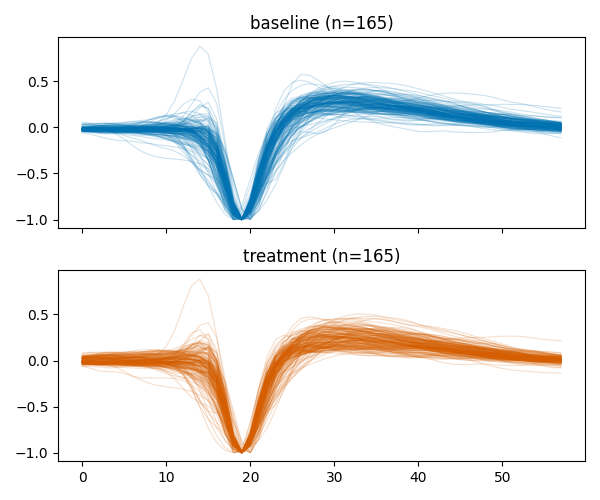

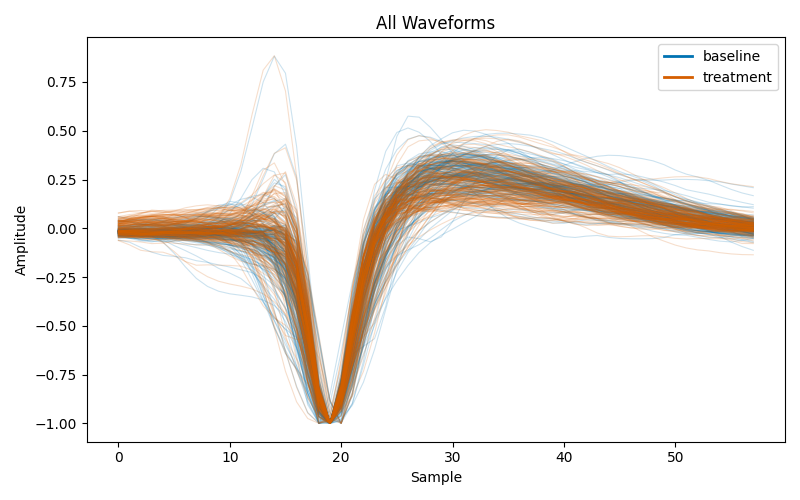

In [64]:
# Load the preprocessed noflip25 data

data_path_base = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_baseline.csv"
data_path_treat = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_treat.csv"

data_list = [data_path_base, data_path_treat] 
data_labels = ['baseline', 'treatment']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)

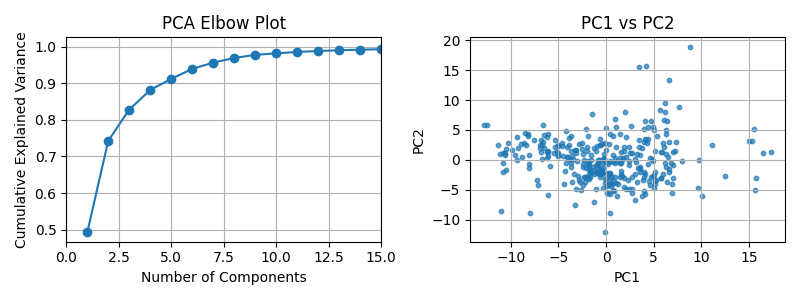

Components that explain 90% of variance: 5


In [65]:
# Run PCA

X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


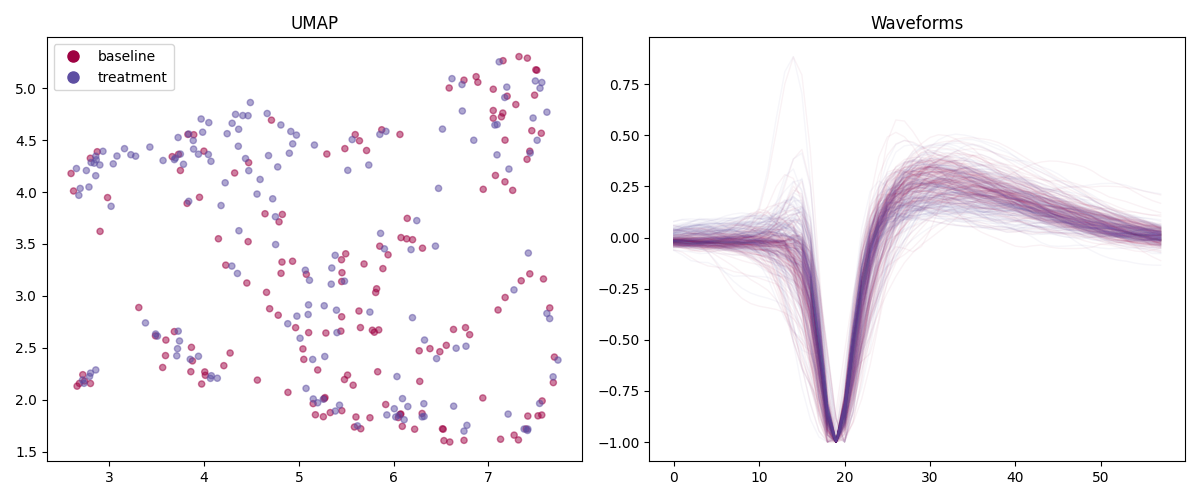

In [76]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=8, resolution = 5, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP with dataset labels
interactive_umap_plot(umap_df, cmap_name="Spectral")

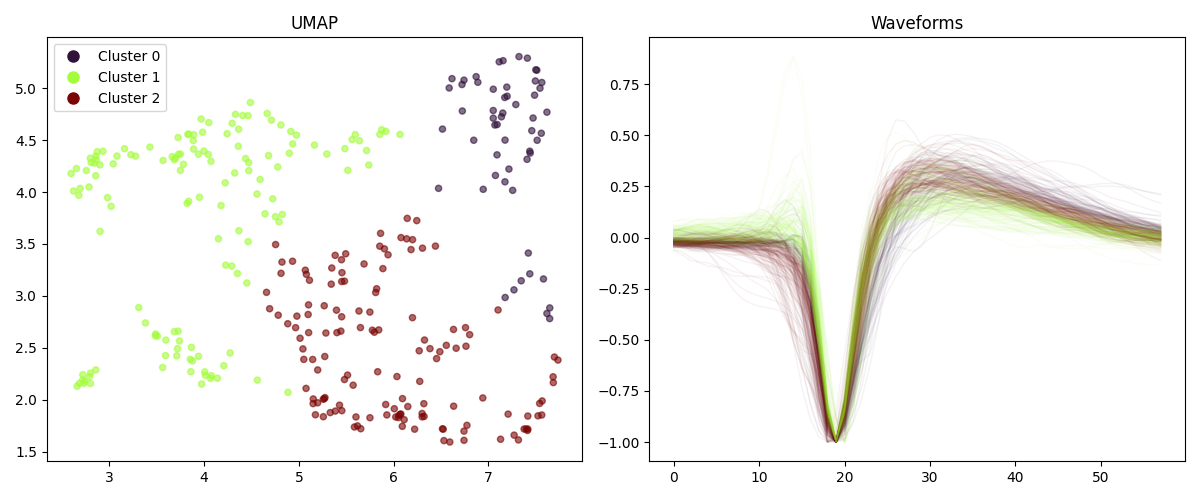

In [77]:
# Plot UMAP with cluster labels
interactive_umap_clusters(umap_df)

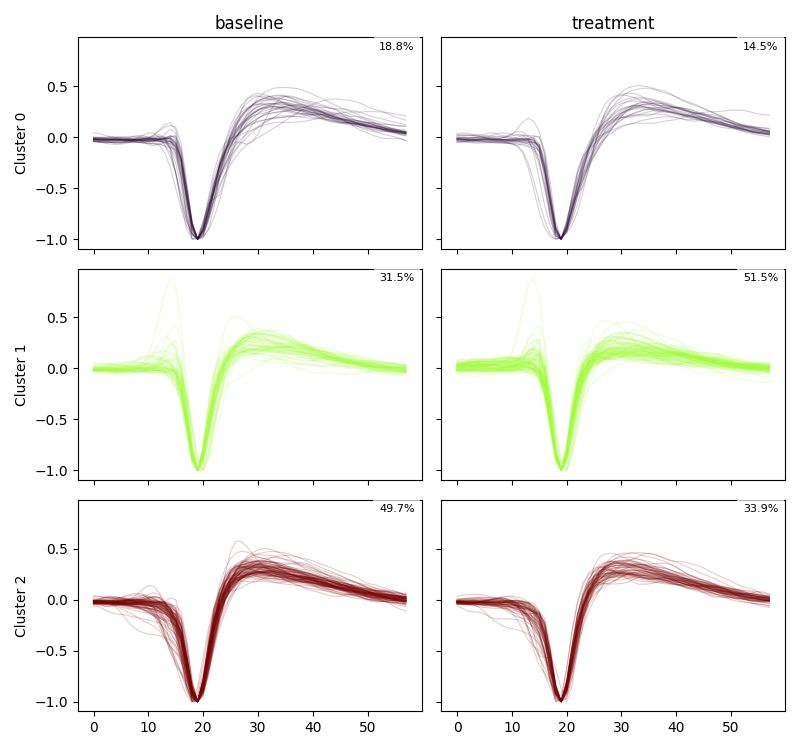

In [78]:
plot_cluster_waveforms(umap_df,plot_mean=False,alpha=0.2, figsize_per_panel=(4, 2.5))

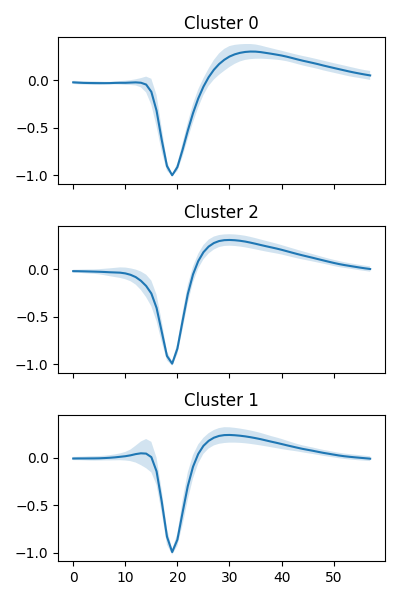

In [87]:
plt.close()

clusters = umap_df['cluster_id'].unique()
n_clusters = len(clusters)

umap_df_base = umap_df[umap_df['dataset'] == 'baseline']
umap_df_treat = umap_df[umap_df['dataset'] == 'treatment']

fig, axes = plt.subplots(n_clusters, 1, figsize=(4, 2*n_clusters), sharex=True, sharey=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df_base[umap_df_base['cluster_id'] == cluster]
    
    waves = np.vstack(cluster_data['waveform'])
    
    mean = waves.mean(axis=0)
    std = waves.std(axis=0)
    
    ax.plot(mean)
    ax.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)
    
    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()

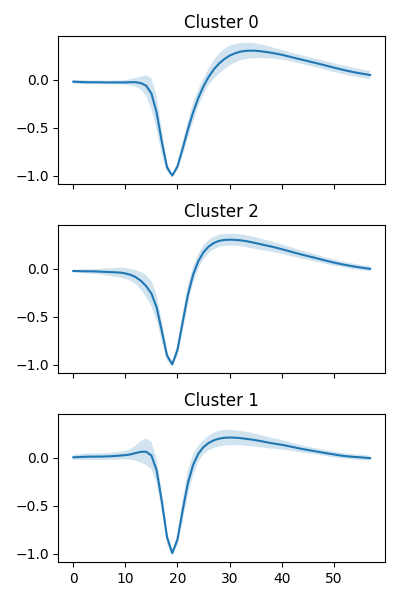

In [88]:
plt.close()

for ax, cluster in zip(axes, clusters):
    cluster_data = umap_df_treat[umap_df_treat['cluster_id'] == cluster]
    
    waves = np.vstack(cluster_data['waveform'])
    
    mean = waves.mean(axis=0)
    std = waves.std(axis=0)
    
    ax.plot(mean)
    ax.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)
    
    ax.set_title(f"Cluster {cluster}")

plt.tight_layout()
plt.show()